In [81]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings 
warnings.filterwarnings('ignore')
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report,accuracy_score,precision_score,recall_score,f1_score
from sklearn.model_selection import train_test_split

#### Exploratory Data Analysis(EDA)

In [82]:
### Loading the data from the csv file
df=pd.read_csv('diabetes1.csv')

In [83]:
df.shape

(768, 9)

In [84]:
### Seeing first 4 columns of the dataset
df.head(4)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0


In [85]:
### Getting the information about the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


#### Hence the given dataset has all numerical columns with 7 of integer type and 2 of float datatype

In [86]:
### statistical information of the dataset
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [87]:
### Checking for missing values
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

##### Hence the given dataset has no missing values

In [88]:
### hecking the duplicates
df.duplicated().sum()

np.int64(0)

##### The dataset has no duplicate values

In [89]:
### Checking for datatypes
df.dtypes

Pregnancies                   int64
Glucose                       int64
BloodPressure                 int64
SkinThickness                 int64
Insulin                       int64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
Outcome                       int64
dtype: object

In [90]:
### checking for outliers
df.boxplot()


<Axes: >

In [91]:
### removing outliers by capping 
def outlier_capping(df,column):

    Q1= df[column].quantile(0.25)

    Q3= df[column].quantile(0.75)

    IQR= Q3-Q1

    lower_extreme= Q1-1.5*IQR

    upper_extreme= Q3+1.5*IQR

    df[column]= df[column].apply(lambda x: lower_extreme if x<lower_extreme else upper_extreme if x>upper_extreme else x)

for col in df.select_dtypes(['int','float']).columns:

    outlier_capping(df,col)

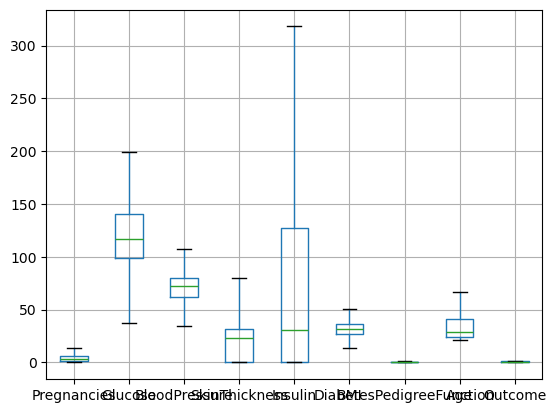

In [129]:
df.boxplot()
plt.show()

In [93]:
 #Now Plotting histplot Of each Numerical Column so as to identify Features Distribution among the dataset

In [94]:
#### first find numercal columns in the dataset
num_col=df.select_dtypes (include=['int64','float64']).columns
num_col

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')

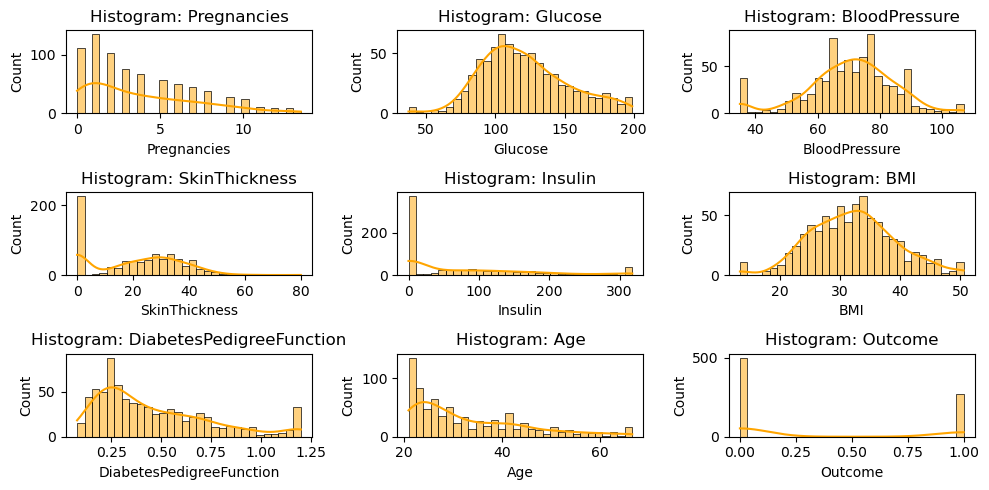

In [95]:
#### Histogram plott for num_ col

plt.figure(figsize=(10,5))
for i, col in enumerate(num_col, 1):
    plt.subplot(3,3, i)
    sns.histplot(df[col], kde=True, bins=30,color='Orange') 
    plt.title(f"Histogram: {col}")
plt.tight_layout()
plt.show()


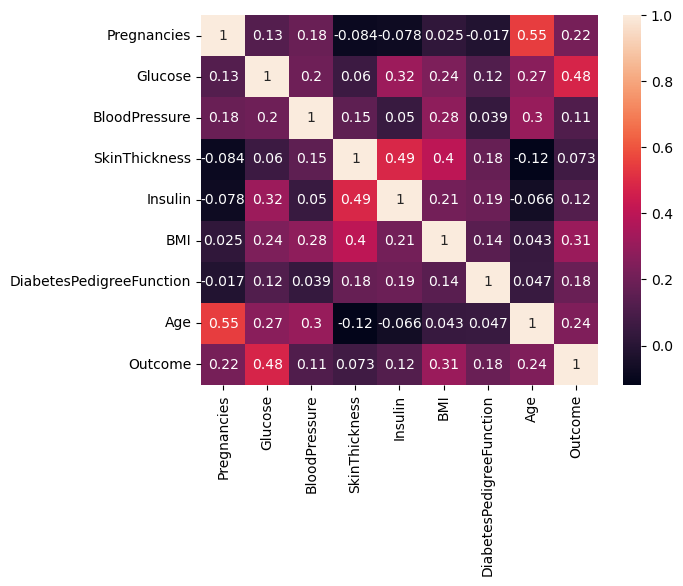

In [96]:
### Now plotting heatmap to find the correlation between the numerical columns
sns.heatmap(df.corr(),annot=True)
plt.show()

#### Data preprocessing

In [97]:
## There are no missing values present, hence no imputaion is neeeded
### There is no categorical data present in the dataset, hence encoding is not needed


In [98]:
#### Splitting the dataset into target and features
features=df.drop('Outcome',axis=1)
target=df['Outcome']

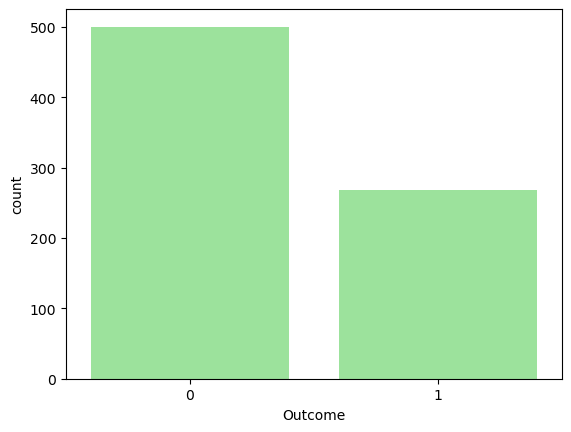

In [99]:
###Checking hte data is balanced or imbalanced by plotting countplot
sns.countplot(x=target,color='LightGreen')
plt.show()

In [100]:
#### Applying scaling technique so as to get data in particular range
### Standard scaler transforms the data into (-3,+3) range
std_sca=StandardScaler()
scaled_data=std_sca.fit_transform(features)
scaled_data

array([[ 0.64714967,  0.86192556,  0.09269135, ...,  0.20935933,
         0.58892732,  1.44569096],
       [-0.84896998, -1.15943299, -0.33020145, ..., -0.78425421,
        -0.37810147, -0.189304  ],
       [ 1.24559754,  1.98490253, -0.47116571, ..., -1.25267202,
         0.74659506, -0.10325164],
       ...,
       [ 0.34792574, -0.00437096,  0.09269135, ..., -0.84103213,
        -0.74949659, -0.27535637],
       [-0.84896998,  0.15605432, -0.75309424, ..., -0.28744744,
        -0.38510892,  1.18753386],
       [-0.84896998, -0.90275254, -0.04827292, ..., -0.24486401,
        -0.50423566, -0.87772293]])

#### Building Predictive Models:

In [101]:
## Hold Out technique to split data into training and testing
x_train, x_test, y_train, y_test = train_test_split(features, target, test_size=0.3, random_state=42, stratify = target)
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(537, 8)
(231, 8)
(537,)
(231,)


#### Using XGBoost Classifier

In [102]:
from xgboost import XGBClassifier
xgb_model = XGBClassifier( n_estimators=100,max_depth=4,learning_rate=0.1,random_state=42)
xgb_model.fit(x_train, y_train)
#### Making the model to learn by fitting the training dataset with the XGBoost model

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=4,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=100,
              n_jobs=None, num_parallel_tree=None, ...)

In [103]:
#### seeing the values predicted by the model
y_pred_xg = xgb_model.predict(x_test)
y_pred_xg

array([0, 0, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0,
       0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0,
       0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1,
       1, 0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0,
       0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0,
       0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0, 0, 1,
       0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1,
       0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0,
       0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0])

### Using LightGBM Model

In [105]:
### importing lightGBM CLassifier model
from lightgbm import LGBMClassifier
lgb_model = LGBMClassifier(n_estimators=100,max_depth=4,learning_rate=0.1,random_state=42)
lgb_model.fit(x_train, y_train)


[LightGBM] [Info] Number of positive: 187, number of negative: 350
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000216 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 602
[LightGBM] [Info] Number of data points in the train set: 537, number of used features: 8
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.348231 -> initscore=-0.626825
[LightGBM] [Info] Start training from score -0.626825
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best 

LGBMClassifier(max_depth=4, random_state=42)

In [63]:
#### seeing the values predicted by the model
y_pred_lgb = lgb_model.predict(x_test)
y_pred_lgb

array([0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0,
       0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0,
       0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0,
       0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1,
       1, 0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0,
       0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0,
       0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0, 0, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1,
       0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1,
       0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0])

In [112]:
##### calculating the performance metrics of the XGBoost Model
cm=confusion_matrix(y_test,y_pred_xg)
cm

array([[129,  21],
       [ 39,  42]])

In [111]:
print(classification_report(y_test, y_pred_xg))

              precision    recall  f1-score   support

           0       0.77      0.86      0.81       150
           1       0.67      0.52      0.58        81

    accuracy                           0.74       231
   macro avg       0.72      0.69      0.70       231
weighted avg       0.73      0.74      0.73       231



In [113]:
### Calculating the performance metrics of LightGBM Model
cm1=confusion_matrix(y_test,y_pred_lgb)
cm1

array([[132,  18],
       [ 36,  45]])

In [115]:
print('Classification report:',classification_report(y_test,y_pred_lgb))

Classification report:               precision    recall  f1-score   support

           0       0.79      0.88      0.83       150
           1       0.71      0.56      0.62        81

    accuracy                           0.77       231
   macro avg       0.75      0.72      0.73       231
weighted avg       0.76      0.77      0.76       231



In [116]:
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'num_leaves': [15, 31, 63]
}

In [117]:
# Optimizing LGB model performence

from sklearn.model_selection import GridSearchCV, cross_val_score, StratifiedKFold

kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_search = GridSearchCV(estimator=lgb_model,
                           param_grid=param_grid,
                           scoring='accuracy',
                           cv=kfold,
                           n_jobs=-1,
                           verbose=1)

grid_search.fit(x_train, y_train)

Fitting 5 folds for each of 81 candidates, totalling 405 fits
[LightGBM] [Info] Number of positive: 187, number of negative: 350
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000180 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 602
[LightGBM] [Info] Number of data points in the train set: 537, number of used features: 8
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.348231 -> initscore=-0.626825
[LightGBM] [Info] Start training from score -0.626825
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[L

GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=LGBMClassifier(max_depth=4, random_state=42), n_jobs=-1,
             param_grid={'learning_rate': [0.01, 0.1, 0.2],
                         'max_depth': [3, 5, 7], 'n_estimators': [50, 100, 200],
                         'num_leaves': [15, 31, 63]},
             scoring='accuracy', verbose=1)

In [118]:
### Finding out the best parameteres
print("Best Parameters:", grid_search.best_params_)

best_model = grid_search.best_estimator_

y_pred_lgb_class = best_model.predict(x_test)

from sklearn.metrics import accuracy_score, classification_report
print("Test Accuracy of LGBM on grid search cv:", accuracy_score(y_test, y_pred_lgb_class))
print(classification_report(y_test, y_pred_lgb_class))

Best Parameters: {'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 200, 'num_leaves': 15}
Test Accuracy of LGBM on grid search cv: 0.7402597402597403
              precision    recall  f1-score   support

           0       0.76      0.87      0.81       150
           1       0.67      0.51      0.58        81

    accuracy                           0.74       231
   macro avg       0.72      0.69      0.69       231
weighted avg       0.73      0.74      0.73       231



In [119]:
# Optimizing XGB model performence

kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
grid_search = GridSearchCV(estimator=xgb_model,
                           param_grid=param_grid,
                           scoring='accuracy',
                           cv=kfold,
                           n_jobs=-1,
                           verbose=1)

grid_search.fit(x_train, y_train)

Fitting 5 folds for each of 81 candidates, totalling 405 fits


GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=False, eval_metric=None,
                                     feature_types=None, feature_weights=None,
                                     gamma=None, grow_polic...
                                     max_cat_to_onehot=None,
                                     max_delta_step=None, max_depth=4,
                                     max_leaves=None, min_child_weight=None,
                                     missing=nan, monotone_constraints=None,
                                     multi_strategy=None, n_estimators=100,
                                     n_jobs=None, num_parallel_tree=None, ...),
             n_jobs=-1,
             param_grid={'learning_rate': [0.01, 0.1, 0.2],
                         'max_depth': [3, 5, 7], 'n_estimators': [50, 100, 200],
                         'num_leaves': [15, 31, 63]},
             scoring='accuracy', verbose=1)

In [120]:
print("Best Parameters:", grid_search.best_params_)

Best Parameters: {'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 200, 'num_leaves': 15}


In [122]:
### Finding out the best model estimator
best_model = grid_search.best_estimator_
y_pred_xgb_class = best_model.predict(x_test)

print("Test Accuracy of XGBM on grid search cv::", accuracy_score(y_test, y_pred_xgb_class))
print(classification_report(y_test, y_pred_xgb_class))

Test Accuracy of XGBM on grid search cv:: 0.7445887445887446
              precision    recall  f1-score   support

           0       0.77      0.87      0.82       150
           1       0.68      0.51      0.58        81

    accuracy                           0.74       231
   macro avg       0.72      0.69      0.70       231
weighted avg       0.74      0.74      0.73       231



#### Comparative Analysis:
##### Compare the performance metrics (e.g., accuracy, precision, recall) of LightGBM and XGBoost models.
##### Accuracy
LightGBM Accuracy: 0.7446
XGBoost Accuracy: 0.7446
Both models show identical accuracy, indicating similar overall classification performance.

###### Precision
LightGBM : - Class 0 :0.77 - Class 1 :0.68
XGBoost : - Class 0 :0.77 - Class 1 :0.68
Both models are better at predicting Class 0 than Class 1.

###### Recall
LightGBM : - Class 0 :0.87 - Class 1 :0.51
XGBoost : - Class 0 :0.87 - Class 1 :0.51
High recall for Class 0
Low recall for Class 1

###### F1-Score
LightGBM : - Class 0 :0.82 - Class 1 :0.58
XGBoost : - Class 0 :0.82 - Class 1 :0.58
Identical F1-scores indicate equal balance between precision and recall for both models.

#### Visualize and interpret the results to identify the strengths and weaknesses of each algorithm.

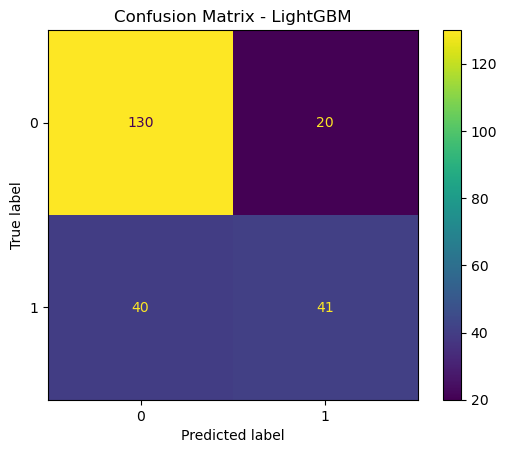

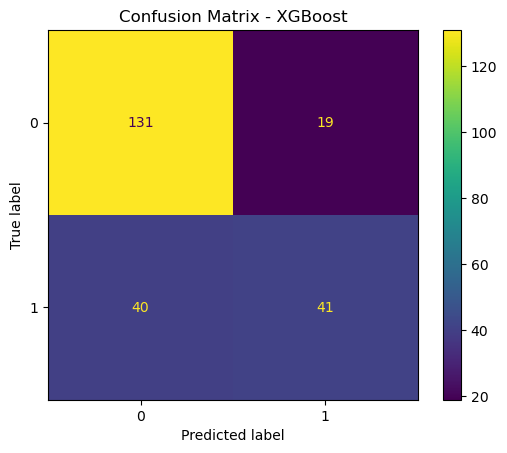

In [127]:
# For LightGBM
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
cm_lgb = confusion_matrix(y_test, y_pred_lgb_class)
ConfusionMatrixDisplay(cm_lgb).plot()
plt.title("Confusion Matrix - LightGBM")
plt.show()

# For XGBoost
cm_xgb = confusion_matrix(y_test, y_pred_xgb_class)
ConfusionMatrixDisplay(cm_xgb).plot()
plt.title("Confusion Matrix - XGBoost")
plt.show()

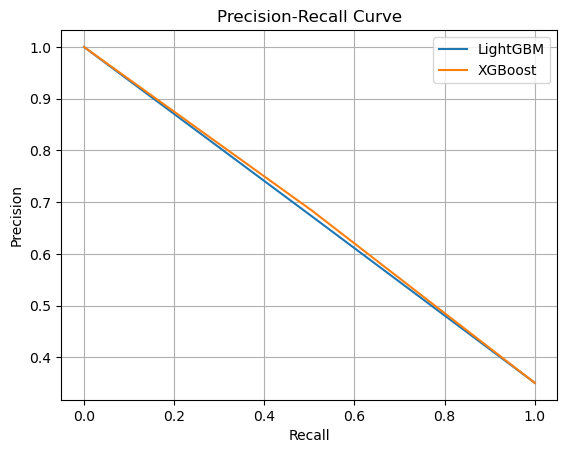

In [128]:
from sklearn.metrics import precision_recall_curve

prec_lgb, rec_lgb, _ = precision_recall_curve(y_test, y_pred_lgb_class)
prec_xgb, rec_xgb, _ = precision_recall_curve(y_test, y_pred_xgb_class)

plt.plot(rec_lgb, prec_lgb, label='LightGBM')
plt.plot(rec_xgb, prec_xgb, label='XGBoost')
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.grid()
plt.show()